# K-Nearest Neighbors (KNN) - Modelos con Datos de Violencia Intrafamiliar

In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [64]:
sns.set(style="whitegrid")

def plot_conf_matrix(y_true, y_pred, title="Matriz de Confusión", labels=["No violencia", "Violencia"]):
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.show()

In [65]:
# Cargar datos
df = pd.read_csv("violencia_unite_data.csv")

# Ver valores únicos de la variable objetivo
print(df["CONDUCENTE"].value_counts(dropna=False))

CONDUCENTE
NaN    20484
1.0    14623
0.0     8038
Name: count, dtype: int64


In [66]:
# Eliminar registros sin valor en CONDUCENTE
df = df.dropna(subset=["CONDUCENTE"])

# Rellenar nulos
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna("ignorado")

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Separar features y target
X = df.drop("CONDUCENTE", axis=1)
y = df["CONDUCENTE"].astype(int)

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

print("Distribución en y_train:", np.bincount(y_train))
print("Distribución en y_test:", np.bincount(y_test))

# Normalización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Distribución en y_train: [ 7234 13160]
Distribución en y_test: [ 804 1463]


📌 Modelo 1: KNN sin balanceo
              precision    recall  f1-score   support

           0       0.53      0.42      0.47       804
           1       0.71      0.79      0.75      1463

    accuracy                           0.66      2267
   macro avg       0.62      0.61      0.61      2267
weighted avg       0.65      0.66      0.65      2267

Matriz de confusión:
[[ 336  468]
 [ 303 1160]]


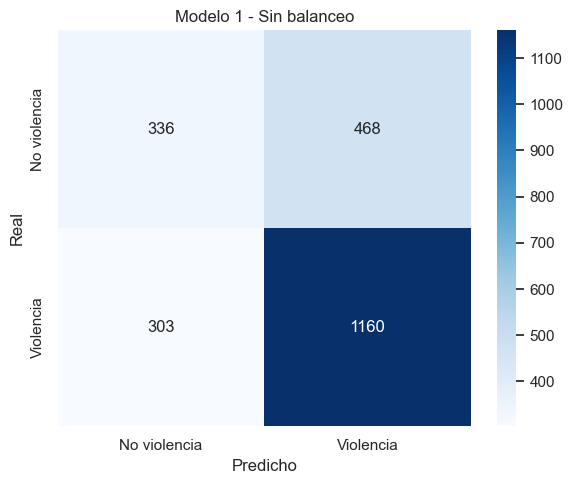

In [67]:
# Modelo 1 - Básico sin balanceo
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train_scaled, y_train)
y_pred1 = knn1.predict(X_test_scaled)

print(" Modelo 1: KNN sin balanceo")
print(classification_report(y_test, y_pred1))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred1))
plot_conf_matrix(y_test, y_pred1, title="Modelo 1 - Sin balanceo")


Distribución original: {1: 13160, 0: 7234}
Usando 7234 muestras de cada clase para balancear

📌 Modelo 2: KNN con undersampling (robusto)
              precision    recall  f1-score   support

           0       0.47      0.64      0.54       804
           1       0.75      0.60      0.67      1463

    accuracy                           0.62      2267
   macro avg       0.61      0.62      0.61      2267
weighted avg       0.65      0.62      0.62      2267

Matriz de confusión:
[[516 288]
 [582 881]]


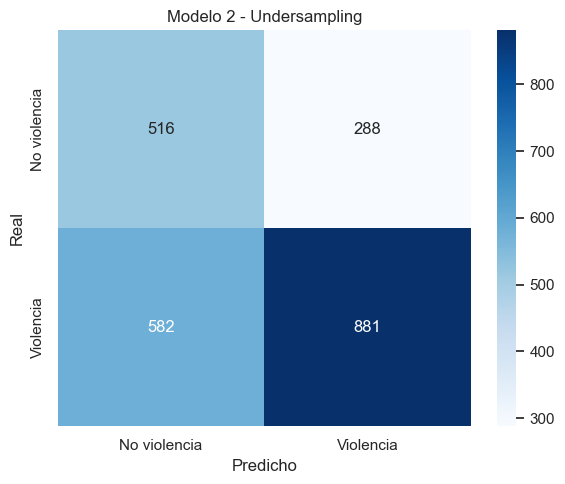

In [68]:
# Modelo 2 - KNN con undersampling robusto
Xy_train = pd.DataFrame(X_train_scaled)
Xy_train["target"] = y_train.values

# Contar clases
class_counts = Xy_train["target"].value_counts()
print("Distribución original:", class_counts.to_dict())

# Identificar clases
min_class = class_counts.idxmin()
maj_class = class_counts.idxmax()

minority = Xy_train[Xy_train["target"] == min_class]
majority = Xy_train[Xy_train["target"] == maj_class]

# Submuestreo realista
n_samples = min(len(minority), len(majority))
print(f"Usando {n_samples} muestras de cada clase para balancear")

minority_down = resample(minority, replace=False, n_samples=n_samples, random_state=42)
majority_down = resample(majority, replace=False, n_samples=n_samples, random_state=42)

# Combinar ambos
train_balanced = pd.concat([minority_down, majority_down])
X_balanced = train_balanced.drop("target", axis=1).values
y_balanced = train_balanced["target"].values

# Entrenar modelo
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_balanced, y_balanced)
y_pred2 = knn2.predict(X_test_scaled)

print("\n Modelo 2: KNN con undersampling (robusto)")
print(classification_report(y_test, y_pred2))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred2))
plot_conf_matrix(y_test, y_pred2, title="Modelo 2 - Undersampling")



 Modelo 3: KNN con umbral 0.3
              precision    recall  f1-score   support

           0       0.65      0.22      0.33       804
           1       0.69      0.93      0.79      1463

    accuracy                           0.68      2267
   macro avg       0.67      0.58      0.56      2267
weighted avg       0.67      0.68      0.63      2267

Matriz de confusión:
[[ 180  624]
 [  97 1366]]


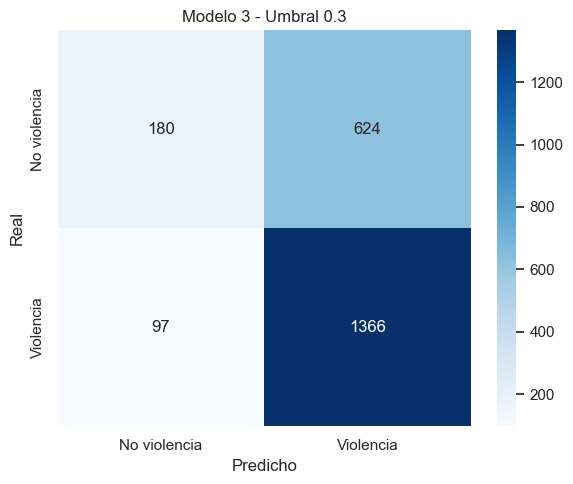

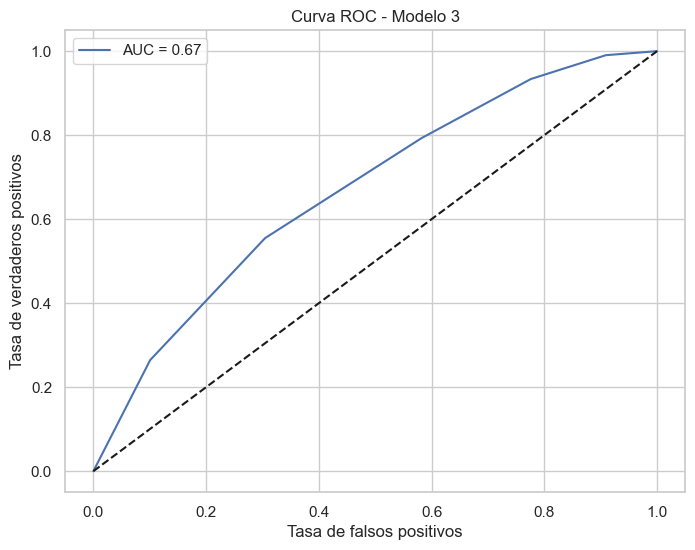

In [69]:
# Modelo 3 - KNN con cambio de umbral
knn3 = KNeighborsClassifier(n_neighbors=5)
knn3.fit(X_train_scaled, y_train)
y_proba = knn3.predict_proba(X_test_scaled)[:, 1]

threshold = 0.3  # más sensible a positivos
y_pred3 = (y_proba >= threshold).astype(int)

print("\n Modelo 3: KNN con umbral 0.3")
print(classification_report(y_test, y_pred3))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred3))
plot_conf_matrix(y_test, y_pred3, title="Modelo 3 - Umbral 0.3")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Modelo 3")
plt.legend()
plt.show()

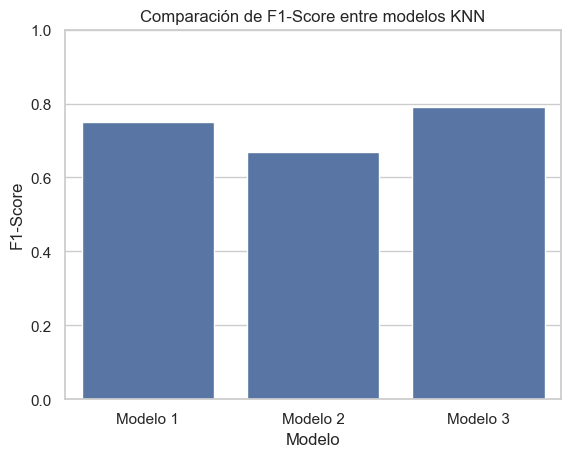

In [70]:
from sklearn.metrics import f1_score

f1_model1 = f1_score(y_test, y_pred1)
f1_model2 = f1_score(y_test, y_pred2)
f1_model3 = f1_score(y_test, y_pred3)

f1_scores = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2", "Modelo 3"],
    "F1-Score": [f1_model1, f1_model2, f1_model3]
})

sns.barplot(data=f1_scores, x="Modelo", y="F1-Score")
plt.title("Comparación de F1-Score entre modelos KNN")
plt.ylim(0, 1)
plt.show()